In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Exercises 
# Matrix operations
A=np.array([[1, 2],
            [3, 4],])

B=np.array([[5, 6], 
            [7, 8]])

# Calculate A+B, AB, and A^TB.
sum= A + B
product = A @ B
transpose = A.T @ B

# Calculate the determinant and trace of A.
det = np.linalg.det(A)
trace = np.trace(A)

# Calculate the Frobenius norm of A.
frobenius = np.linalg.norm(A,'fro')

print("A+B:\n", sum)
print("AB:\n", product)
print("A^TB:\n", transpose)
print("Determinant of A:", det)
print("Trace of A:", trace)
print("Frobenius norm of A:", frobenius)


A+B:
 [[ 6  8]
 [10 12]]
AB:
 [[19 22]
 [43 50]]
A^TB:
 [[26 30]
 [38 44]]
Determinant of A: -2.0000000000000004
Trace of A: 5
Frobenius norm of A: 5.477225575051661


Eigenvalue: 3.0, Eigenvector: [0.89442719 0.4472136 ]
Av: [2.68328157 1.34164079], λv: [2.68328157 1.34164079]
Av == λv: True
Eigenvalue: 2.0, Eigenvector: [0.70710678 0.70710678]
Av: [1.41421356 1.41421356], λv: [1.41421356 1.41421356]
Av == λv: True
Reconstructed A:
 [[ 4. -2.]
 [ 1.  1.]]


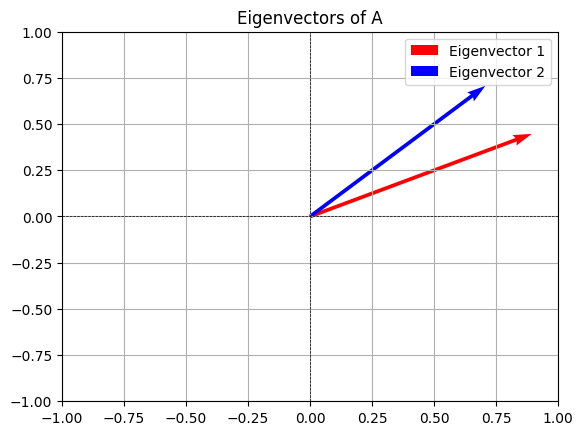

In [6]:
A = np.array([[4, -2],
              [1, 1]])

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# Verify that Av=λv for each eigenvector.
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lambda_v = eigenvalues[i] * v
    Av = A @ v
    print(f"Eigenvalue: {eigenvalues[i]}, Eigenvector: {v}")
    print(f"Av: {Av}, λv: {lambda_v}")
    print("Av == λv:", np.allclose(Av, lambda_v))

# Reconstruct A=VΛV^−1
V = eigenvectors
Λ = np.diag(eigenvalues)
A_reconstructed = V @ Λ @ np.linalg.inv(V)

print("Reconstructed A:\n", A_reconstructed)

# Plot the original and transformed eigenvectors to see how their directions behave
plt.quiver(0, 0, eigenvectors[0, 0], eigenvectors[1, 0], angles='xy', scale_units='xy', scale=1, color='r', label='Eigenvector 1')
plt.quiver(0, 0, eigenvectors[0, 1], eigenvectors[1, 1], angles='xy', scale_units='xy', scale=1, color='b', label='Eigenvector 2')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid()
plt.title('Eigenvectors of A')
plt.legend()
plt.show()

In [7]:
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])

# Compute SVD
U, s, Vh = np.linalg.svd(A, full_matrices=False)

# Original diagonal matrix
Sigma = np.diag(s)

# Pseudoinverse of Sigma
Sigma_plus = np.zeros((Sigma.shape[1], Sigma.shape[0]))

for i in range(len(s)):
    if s[i] != 0:
        Sigma_plus[i, i] = 1 / s[i]

    else:
        Sigma_plus[i, i] = 0

# Reconstruct A
A_reconstructed = U @ Sigma @ Vh

# Compute pseudoinverse
A_pseudoinverse = Vh.T @ Sigma_plus @ U.T

# Compare
print("Reconstructed A:\n", A_reconstructed)
print("\nPseudoinverse using SVD:\n", A_pseudoinverse)
print("\nPseudoinverse using NumPy:\n", np.linalg.pinv(A))

# Verify AA+A = A
print("\nAA+A:\n", A @ A_pseudoinverse @ A)
print("\nVerification:", np.allclose(A @ A_pseudoinverse @ A, A))

Reconstructed A:
 [[1. 2.]
 [3. 4.]
 [5. 6.]]

Pseudoinverse using SVD:
 [[-1.33333333 -0.33333333  0.66666667]
 [ 1.08333333  0.33333333 -0.41666667]]

Pseudoinverse using NumPy:
 [[-1.33333333 -0.33333333  0.66666667]
 [ 1.08333333  0.33333333 -0.41666667]]

AA+A:
 [[1. 2.]
 [3. 4.]
 [5. 6.]]

Verification: True


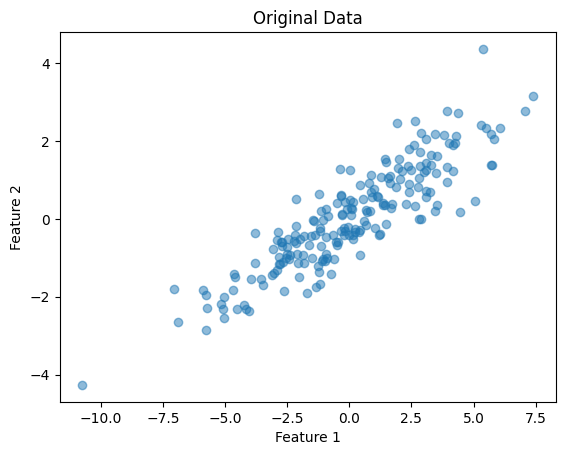

Reconstruction Error (One Component): 0.16172116583152074


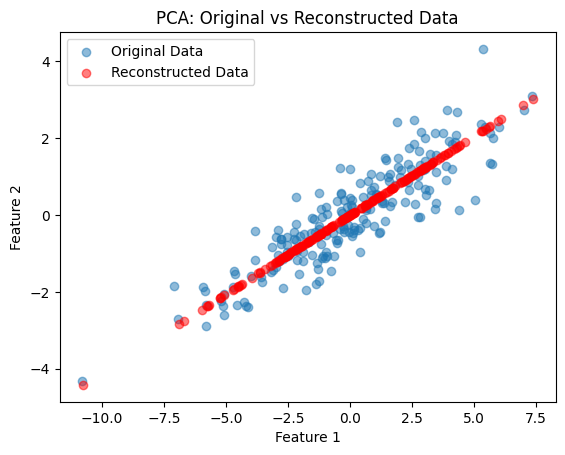

In [8]:
np.random.seed(42)

X = np.random.randn(200, 2)
A = np.array([[3, 1],
              [1, 1]])

X = X @ A

# Plot the original data
plt.scatter(X[:, 0], X[:,1], alpha=0.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")
plt.show()

# Center the data by subtracting its mean
X_centered = X - np.mean(X, axis=0)

# Calculate the covariance matrix
cov_matrix = np.cov(X_centered.T)

# Find its eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Identify the first principal component
first_pc = eigenvectors[:,np.argmax(eigenvalues)]

# Project the data onto the first principal component
X_projected = X_centered @ first_pc

# Reconstruct the data using only one component
X_reconstructed = np.outer(X_projected, first_pc)

# Calculate the reconstruction error
reconstruction_error = np.mean((X_centered - X_reconstructed) ** 2)

print("Reconstruction Error (One Component):", reconstruction_error)

# Plot the original and reconstructed data
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, label="Original Data")
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.5, label="Reconstructed Data", color='r')     
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("PCA: Original vs Reconstructed Data")
plt.legend()
plt.show()


Optimal w using pseudoinverse:
 [[2.98495881 0.98495881]
 [1.00446585 1.00446585]]
Optimal w using np.linalg.lstsq:
 [[2.98495881 0.98495881]
 [1.00446585 1.00446585]]


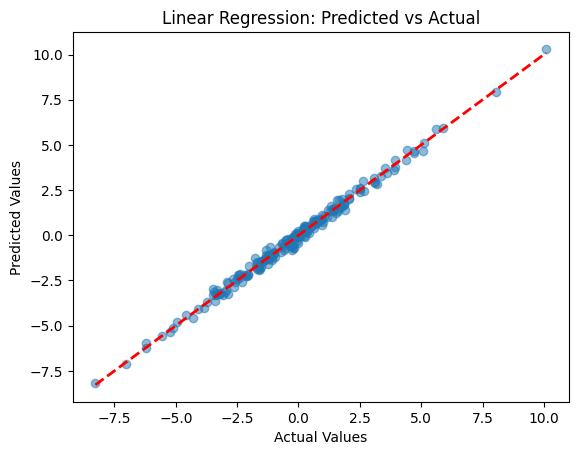

Mean Squared Error: 0.0448839375447386


In [9]:
# Generate synthetic data with two input features.

X = np.random.randn(100, 2)
w = np.array([[3, 1],
              [1, 1]])


# Add random noise to the output.
y = X @ w + np.random.randn(100, 1) * 0.2

# Find the optimal w using the pseudoinverse.
w_pseudo = np.linalg.pinv(X) @ y

# Compare it with np.linalg.lstsq.
w_lstsq, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
print("Optimal w using pseudoinverse:\n", w_pseudo)
print("Optimal w using np.linalg.lstsq:\n", w_lstsq)

# Plot predicted versus actual values.
plt.scatter(y, X @ w_pseudo, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Predicted vs Actual")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.show()

# Calculate the mean squared error.
mse = np.mean((y - X @ w_pseudo) ** 2)
print("Mean Squared Error:", mse)

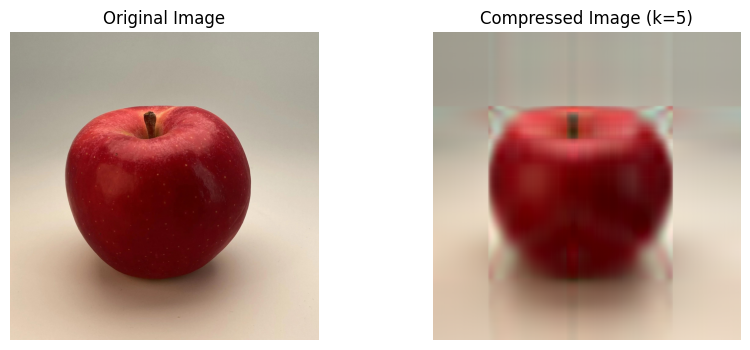

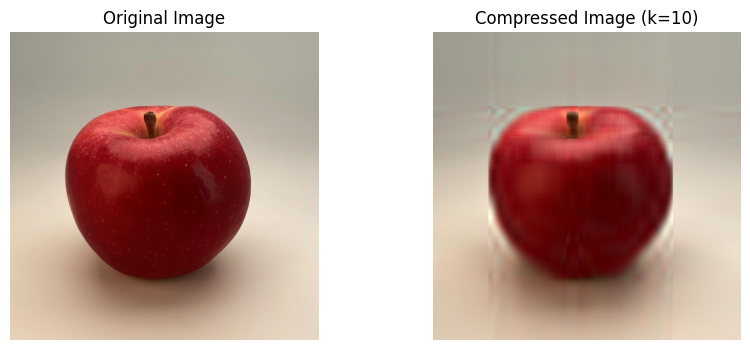

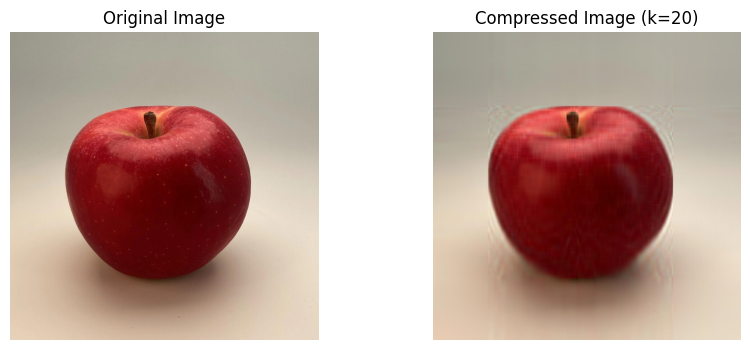

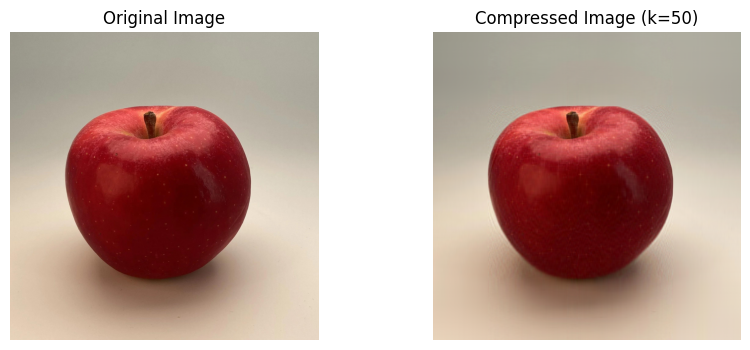

In [22]:
# Load RGB image
X = plt.imread("apple.jpeg")[:, :, :3]

# Normalize if values are in 0–255
if X.max() > 1:
    X = X / 255.0

# Reconstruct using different numbers of singular values
for k in [5, 10, 20, 50]:
    channels = []

    for c in range(3):
        # Extract one color channel
        X_channel = X[:, :, c]

        # Compute SVD
        U, s, Vh = np.linalg.svd(X_channel, full_matrices=False)

        # Reconstruct the channel
        X_k = U[:, :k] @ np.diag(s[:k]) @ Vh[:k, :]

        channels.append(X_k)

    # Combine the three reconstructed channels
    X_compressed = np.stack(channels, axis=2)
    X_compressed = np.clip(X_compressed, 0, 1)

    # Display
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(X)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(X_compressed)
    plt.title(f"Compressed Image (k={k})")
    plt.axis("off")

    plt.show()